In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
df=pd.read_csv("house_price_dataset.csv")

In [ ]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Parking,House_Age,Location_Rating,Distance_City_km,Price
0,3974,4,1,0,9,4,26,19053000
1,1660,5,4,0,5,3,21,9640000
2,2094,1,1,2,24,7,18,10233000
3,1930,5,3,2,29,8,13,11245000
4,1895,5,1,3,17,4,11,10497500


In [ ]:
df.shape

(100, 8)

In [ ]:
df.dtypes

,0
Area_sqft,int64
Bedrooms,int64
Bathrooms,int64
Parking,int64
House_Age,int64
Location_Rating,int64
Distance_City_km,int64
Price,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area_sqft         100 non-null    int64
 1   Bedrooms          100 non-null    int64
 2   Bathrooms         100 non-null    int64
 3   Parking           100 non-null    int64
 4   House_Age         100 non-null    int64
 5   Location_Rating   100 non-null    int64
 6   Distance_City_km  100 non-null    int64
 7   Price             100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [ ]:
df.isnull().sum()

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Parking,0
House_Age,0
Location_Rating,0
Distance_City_km,0
Price,0


In [ ]:
print(df.duplicated().sum())

0


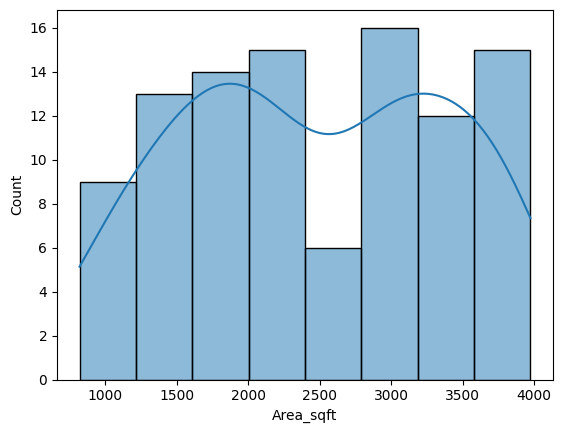

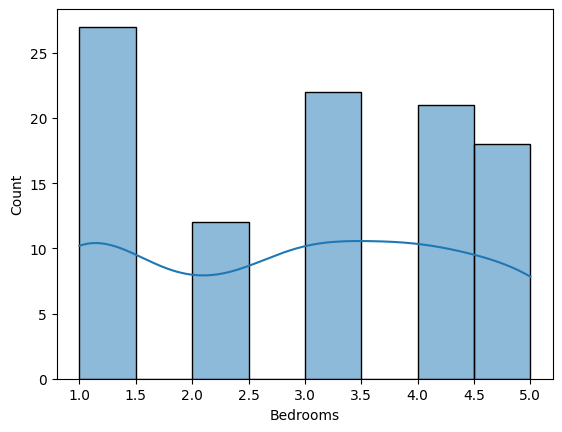

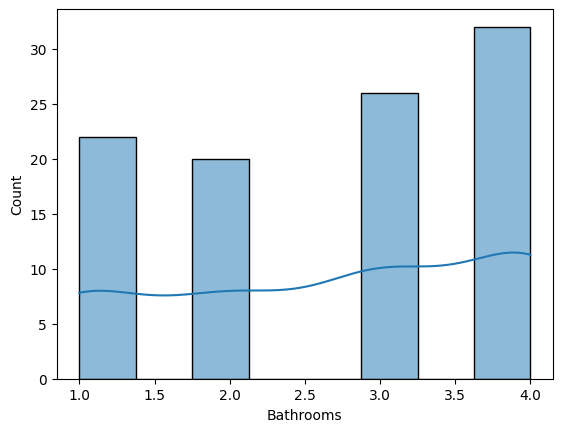

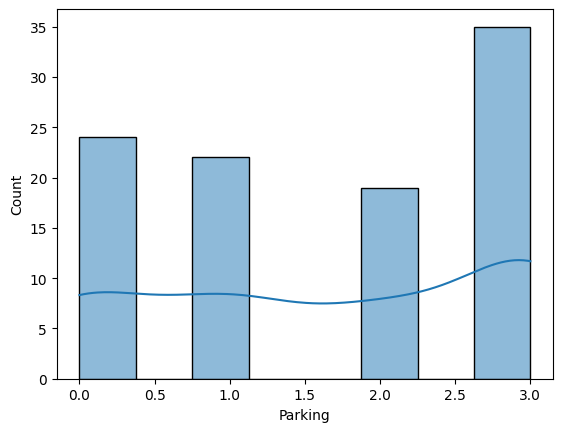

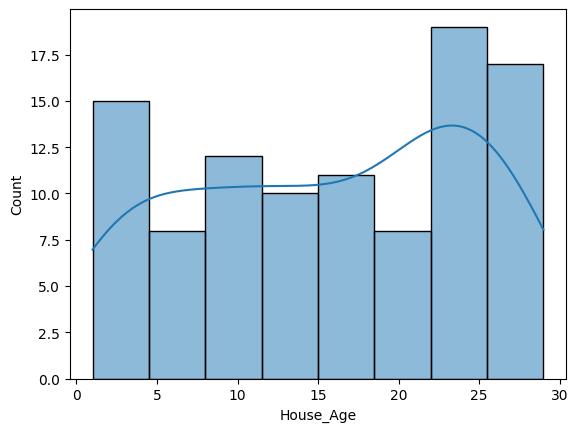

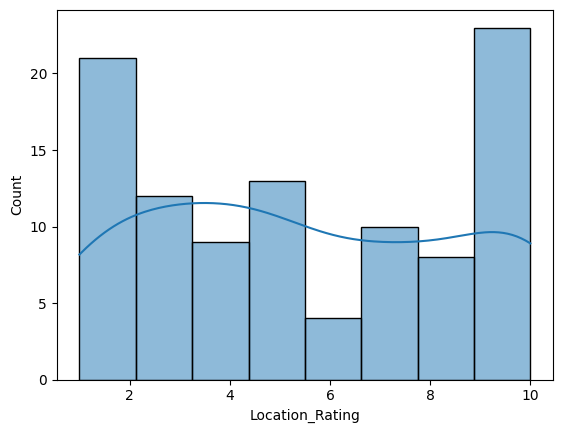

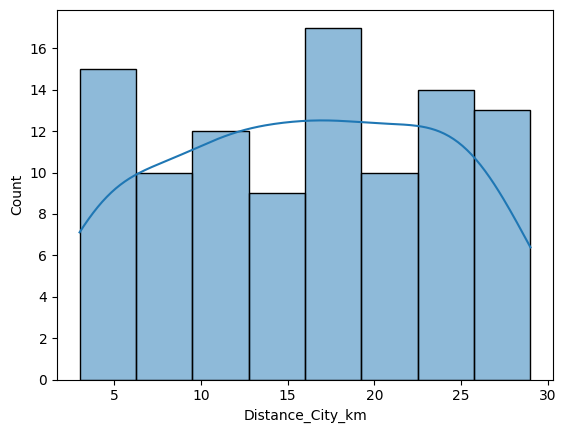

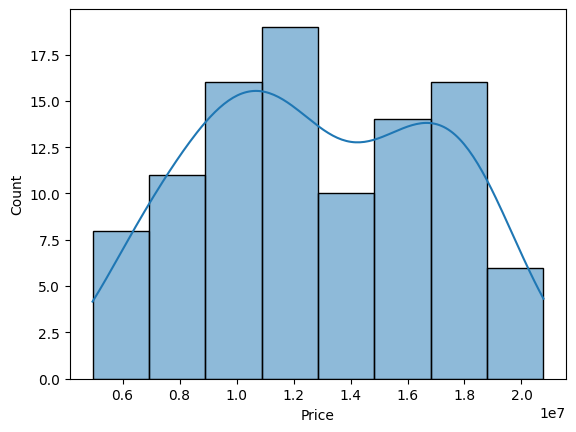

In [ ]:
conti=['Area_sqft','Bedrooms','Bathrooms','Parking','House_Age','Location_Rating','Distance_City_km','Price'];
for i in conti:
    sns.histplot(data=df,x=i,kde=True)
    plt.show()

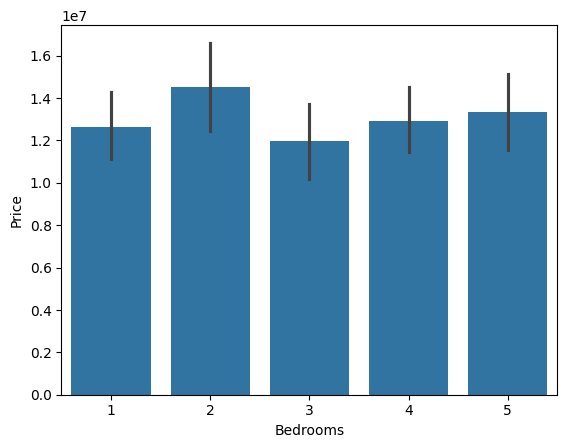

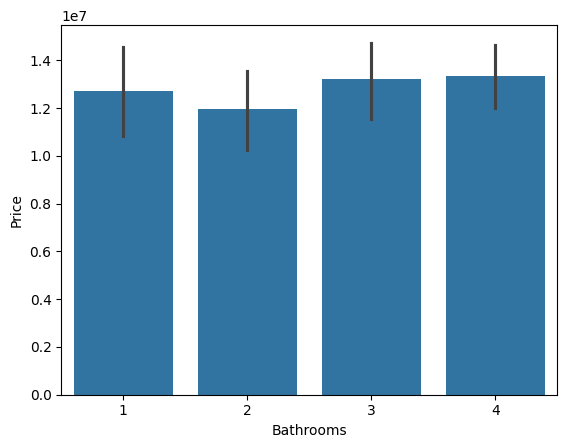

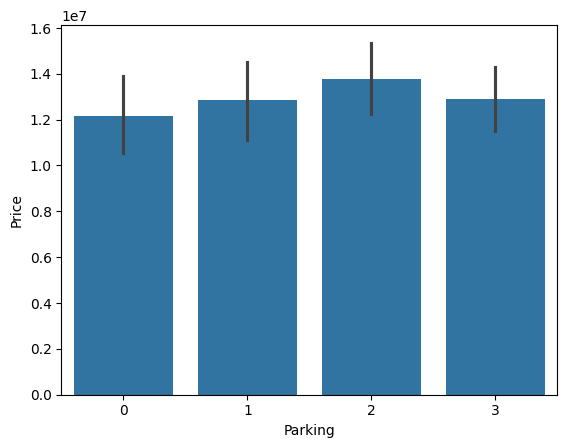

In [ ]:
var=['Bedrooms','Bathrooms','Parking'];
for i in var:
    sns.barplot(data=df,x=i,y="Price")
    plt.show()

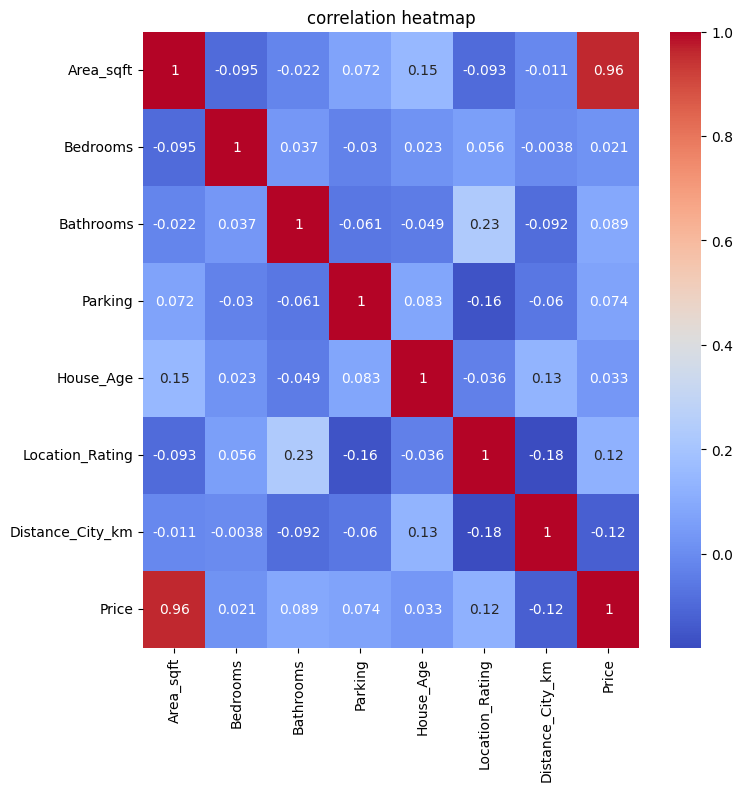

In [ ]:
corr_matrix=df.corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [ ]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:
y_pred=model.predict(X_test)
print(y_pred)

[ 9364500. 10690000. 17954000. 18595500. 11781500. 19142500. 12027500.
 16576500.  5515000. 19053000. 17149500. 18328000. 16428500. 16661000.
 11512000. 10497500.  8550500. 11600000. 14737500.  6943000.]


In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Squared Error: 8.153200337090994e-18
R2 Score: 1.0


In [ ]:
comparision=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(comparision.head())

     Actual   Predicted
0   9364500   9364500.0
1  10690000  10690000.0
2  17954000  17954000.0
3  18595500  18595500.0
4  11781500  11781500.0


In [ ]:
new_house=pd.DataFrame({
    'Area_sqft':[3500],
    'Bedrooms':[3],
    'Bathrooms':[2],
    'Parking':[1],
    'House_Age':[5],
    'Location_Rating':[4.5],
    'Distance_City_km':[20]
    })
predicted_price=model.predict(new_house)
print("predicted price",predicted_price)

predicted price [17475000.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


/tmp/ipykernel_1558/2996311846.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


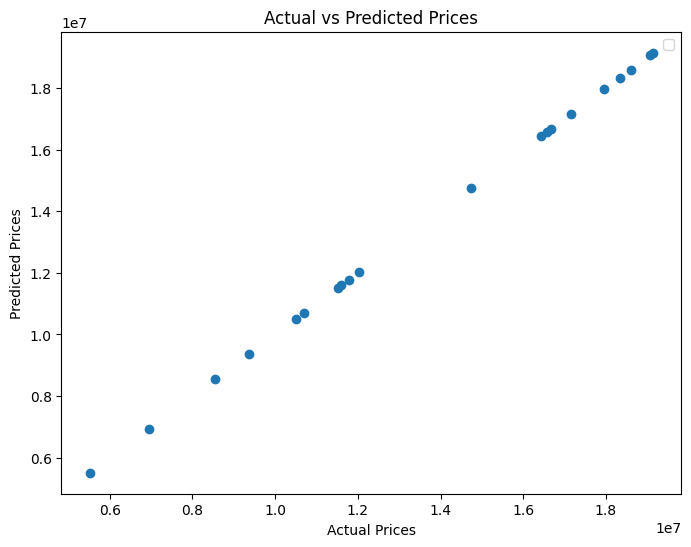

In [ ]:
#comparing actual and predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()